In [92]:
import pandas as pd
import numpy as np
from pathlib import Path
base_path = Path('/content/drive/Shareddrives/KN Solvro/03. Projekty/Wakacyjne Wyzwanie 20256/ML/notebooki/1_Przetwarzanie i wizualizacja danych') # change path here!

# Klasyfikacja pasażerów Titanica
Nie wiemy czy dla DiCaprio było miejsce na drzwiach, ale wiemy że grdyby był tam Wojfer87 to by z nimi wyciskał pompki na górze lodowej. Teraz twoja pora na wyciskanie.
#Twoje zadnie to:
**stworzenie modelu przewidującego szanse przeżycia katastrofy Titanica**.

![https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png](https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png "Wojfer")



#### Twoim celem będzie jest wytrenowanie modeli do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

Poniżej znajdziesz pytania, które mogą być pomocne w zadaniu:

- Czego nauczyło Cię o badanym zbiorze danych poprzednie zadanie? Jak możesz wykorzystać wyciągnięte z niego wnioski w procesie tworzenia modelu?
1. Nauczyło o korelacji zmiennych między sobą oraz ich właściwościach: bo w zależności od tego będzie brana odpowiednia metoda.
- Jak przeprowadzenie standaryzacji danych może wpływać na zachowanie modelu?
1. Im bardziej spójne są dane(mają taki sam format, brakuje w nich szumu itd.) tym precyzyjniej będą przewidywania modelu
- Co mój model robi i w jaki sposób?
- Jak nie przetrenować wybranego modelu?
1. Ograniczyłam DecisionTree przez maksymalną liczbę poziomów(3)
- Jaki wynik klasyfikacji możemy uznać za *dobry*?
1. Ja bym zrobiłam z tego skalę:

minimum - DummyClassifier

maximum - precision i f1 == 1.0
Po środku - rzeczywistość. Musimy dążyć do 1(ale nie przez wyciek danych ;] )


Wymagania:
- Wypisz obserwacje z pierwszego zadania, które pomogą Ci w tym. Co było przydatne, a co okazało się bezużyteczne?
1. Faktycznie, z przydatnego mam wykresy z ubiegłego notatnika(jakie zmienne są najbardziej znaczące), ale nie chcę tutaj to przenosić. Znaczące dane umieściłam w tabicy na dole(wywołanie head)
Ale przeniosę wnioski ogólne ze starego notatnika:
---
- Najbardziej decydującym faktorem dla przeżycia są płeć, wiek i klasa(czyli zamożność).
- Z tego wnioskujemy, że największe szanse na przeżycie mają kobiety, które wykupiły 1 klasę oraz mają w okolicach 30 lat lub są dziećmi do 2-3 lat.
- Może Deck miały znaczenie, ale jest zbyt dużo nieznanych nam danych(77%)
---
- ✔ [Nie doprowadź](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) do ~~przecieku statku~~ wycieku danych (np. nie ucz modelu na danych testowych). Nauczone modele odpal na danych treningowych i testowych - opisz uzyskane wyniki.
-  ✔ Stwórz baseline, czyli dla porównania sprawdź jak z zadaniem radzi sobie [Dummy Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html) (jeśli Twój docelowy model radzi sobie gorzej - uciekaj)
- ✔ Przeprowadź badania na dwóch wybranych modelach uczenia maszynowego (np. spośród: drzew decyzyjnych, SVM, MLP, KNN, z gwiazdką [XGBoost](https://xgboost.readthedocs.io/en/stable))
-  W badaniach użyj wybranych metryk. Wybór uzasadnij.
1. Wybrałam f1 jako najważniejszą metrykę, ponieważ jest kombinacją precyzji(prawidłowe wyniki) i czułości(recall)(faktyczny odsetek prawidłowych odpowiedzi). Jest po prostu uniwersalna. Ale te 2 osobno też rozpatruję
- Dla każdego modelu wybierz co najmniej dwa hiperparametry i przeprowadź badania zależności wyników metryk od wartości hiperparametrów. Zwizualizuj wszystko ładnie, zastanów się dlaczego tak mogło być i wyciągnij i wypisz wnioski.
- Podsumuj przeprowadzone badania, wypisz wnioski.

Niezmiennie, zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Jeśli chcesz, możesz sprawdzić (przyjmując pewne założenia), jakie byłyby Twoje szanse na Titanicu.

Uwaga! Jeśli Titanic to dla Ciebie nic i baaaaardzo chcesz to możesz w ramach tego zadania zająć się [bardziej wymagającym](https://archive.ics.uci.edu/dataset/365/polish+companies+bankruptcy+data) zbiorem.

In [93]:
titanic_df = pd.read_csv('/content/titanic_clean_final.csv', index_col='PassengerId')

In [94]:
titanic_df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex,Title,Deck,Embarked_S,Embarked_C,Embarked_Q
PassengerId,,,,,,,,,,,,
1,0,3,22.0,1,0,14.5000,0,0,0,1,0,0
2,1,1,38.0,1,0,71.2833,1,2,3,0,1,0
3,1,3,26.0,0,0,14.5000,1,1,0,1,0,0
4,1,1,35.0,1,0,53.1000,1,2,3,1,0,0
5,0,3,35.0,0,0,14.5000,0,0,0,1,0,0


#BRUDNOPIS; MYŚLI PRZED UCZENIEM
Teraz wypiszę tu swoje myśli na ten temat:
- Decydującymi o tym zmiennymi(by nie wprowadzać zbyt dużo parametrów) będą tylko 3 lub 4 zmienne: age, sex, Pclass, Fare
-  Mój wybór modelu(typu) pada na drzewo decyzyjne, ponieważ przewidujemy "Przeżył: 0 lub 1" + mamy raczej 0/1 kryteria typu płeć oraz Pclass. Wyjątkiem jest Fare, ale model wyliczy chyba po jakiej wartości szansa jest najwyższa lub najniższa.
Dlaczego nie pasują inne: nie mamy ani klasterów(bo potrzebują większego rozkładu wartości a nie 0-1), ta sama przyczyna z regresją.
- Nauczać chcę metodą kroswalidacji - będę miała 5 fałdów. Te 5 zajmą 90% danych, a wszystko inne będzie zestawem testowym finalnym. To będzie efektywniejsze + mogę sprawdzić efekty między fałdami.

Mój plan:
1.  ✔  Usuwamy wszystkie inne zmienne oprócz tych 4 z df(no i survived zostawiamy, a to jak bez odpowedzi będzie się uczył)(usuwamy tylko w wybranych, testowych zestawach)
2. ✔ Dzielimy zbiór na treningowy i testowy.
3. ✔ Trening
4. Analiza wyników + finał
(P.S.: plan ten jest raczej ogólny, piszę to raczej jako to-do list)





In [95]:
#usuwam niepotrzebne dane:
titanic_df.drop(columns=['SibSp', 'Parch', 'Title', 'Deck', 'Embarked_S', 'Embarked_Q', 'Embarked_C' ], inplace=True)
#f-ja sprawdzania widoku i info df-u
def disp(dataframe):
  display(dataframe.head())
  display(dataframe.info())
disp(titanic_df)

,Survived,Pclass,Age,Fare,Sex
PassengerId,,,,,
1,0,3,22.0,14.5000,0
2,1,1,38.0,71.2833,1
3,1,3,26.0,14.5000,1
4,1,1,35.0,53.1000,1
5,0,3,35.0,14.5000,0


<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Age       891 non-null    float64
 3   Fare      891 non-null    float64
 4   Sex       891 non-null    int64  
dtypes: float64(2), int64(3)
memory usage: 41.8 KB


None

Teraz warto zrobić DummyClassifier, by ustawić minimalny próg przejścia(no bo nie może randomowe zgadywnie wyniku być lepsze od modelu)

In [96]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split # Dodano brakujący import

X = titanic_df.drop(columns=['Survived'])
y = titanic_df['Survived']

#dzielimy dane na train i test
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=.8, shuffle=True)

#sam "model"
model = DummyClassifier(strategy = 'uniform')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
confusion_matrix(y_test, y_pred)

              precision    recall  f1-score   support

           0       0.57      0.51      0.54       100
           1       0.46      0.52      0.49        79

    accuracy                           0.51       179
   macro avg       0.51      0.51      0.51       179
weighted avg       0.52      0.51      0.52       179



array([[51, 49],
       [38, 41]])

---
##DRZEWO Z CROSSWALIDACJĄ
Chcę sprawdzić, na ile model jest efektywny przed wersją oficjalną



In [97]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

#Kroswalidacja

# Model DecisionTree
model_cros = DecisionTreeClassifier(max_depth=5, random_state=42) # Added random_state for reproducibility

# Kroswalidacja ma 5 poziomów
prediction_cros = cross_val_score(model_cros, X_train, y_train, cv=5, scoring='accuracy')

print(f"Accuracy: {prediction_cros}")

print(f"Mean Accuracy: {prediction_cros.mean()}")
print(f"Standard Deviation: {prediction_cros.std()}")

Accuracy: [0.73426573 0.83216783 0.78873239 0.78169014 0.85211268]
Mean Accuracy: 0.7977937555402345
Standard Deviation: 0.04125376693022042


##WNIOSKI:
 Model jest całkiem efektywny

---

##DECISION TREE: CLASSIC

A teraz oficjalna wersja:

In [98]:
#DECISION TREE: CLASSIC
from sklearn.model_selection import cross_val_score
import sklearn.metrics as metrics
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier


# sam model
model_drzewo = DecisionTreeClassifier(random_state=42, max_depth=5)
model_drzewo.fit(X_train, y_train)
prediction_drzewo = model_drzewo.predict(X_test)

print(metrics.classification_report(y_test, prediction_drzewo))

              precision    recall  f1-score   support

           0       0.79      0.76      0.78       100
           1       0.71      0.75      0.73        79

    accuracy                           0.75       179
   macro avg       0.75      0.75      0.75       179
weighted avg       0.76      0.75      0.75       179



##WNIOSKI:
- Zwykłe drzewo decyzyjne pokazuje całkiem niezłą precyzję(75%). Chociaż, wciąż jest przestrzeń do ulepszeń.
- Faktycznie kroswalidacja na koniec daje lepsze wyniki(mean acc.), jednak różnica nie jest zbyt wielka.

Ale najważniejsze, że jest lepiej niż DummyClassifier.




---


---
#EKSPERYMENT: REGRESJA LOGISTYCZNA

- DLA PROWADZĄCEGO: tą część nie zaliczajcie do leaderboardu, ponieważ tu mi pomogło AI, kiedy pytałam jak można ulepszyć wynik oraz jakiego innego modelu można tu użyć(ponieważ te pokazane w dokumencie nie mają w tym datasecie oraz przy tych zmiennych sensu, a przynajmniej dla mnie).

###CHWILA TEORII
- Dany algorytm rozwiązuje problem regresji liniowej: zamiast dążyć do +∞, dąży do tylko 0 lub 1, podobnie daje wynik.
Wzór+wykres:
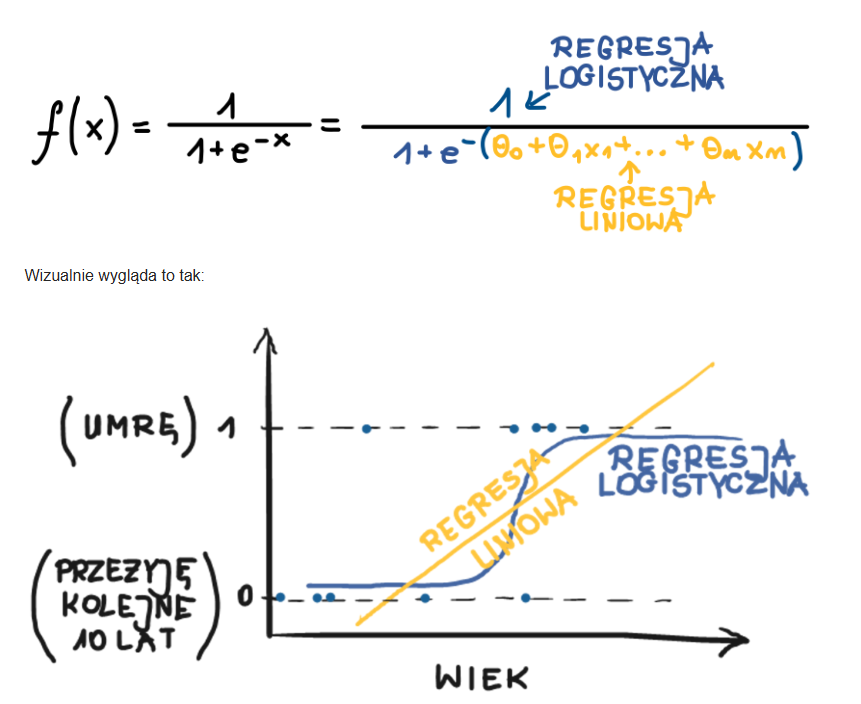

In [99]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

import pandas as pd
import numpy as np

#tworzenie modelu
log_reg = LogisticRegression(random_state=42)
#kroswalidacja, sprawdzamy
cv_scores = cross_val_score(log_reg, X_train, y_train, cv=4, scoring='accuracy')

print(f"Accuracy: {cv_scores}")
print(f"Mean Accuracy: {np.mean(cv_scores):.4f}\n")

#prawdziwy trening:
log_reg.fit(X_train, y_train)

#Ostateczny test
y_pred = log_reg.predict(X_test)

#wyniki:
print(metrics.classification_report(y_test, y_pred))

Accuracy: [0.70786517 0.87078652 0.74157303 0.78651685]
Mean Accuracy: 0.7767

              precision    recall  f1-score   support

           0       0.78      0.82      0.80       100
           1       0.76      0.71      0.73        79

    accuracy                           0.77       179
   macro avg       0.77      0.76      0.77       179
weighted avg       0.77      0.77      0.77       179



##WNIOSKI:

- Regresja logistyczna jest faktycznie prawie równa decision tree w efektywności, ale w aspekcie f1(średnia precyzji i czułości) drzewo jest lepsze(a to jest w mojej klasyfikacji najważniejszą metryką)

---

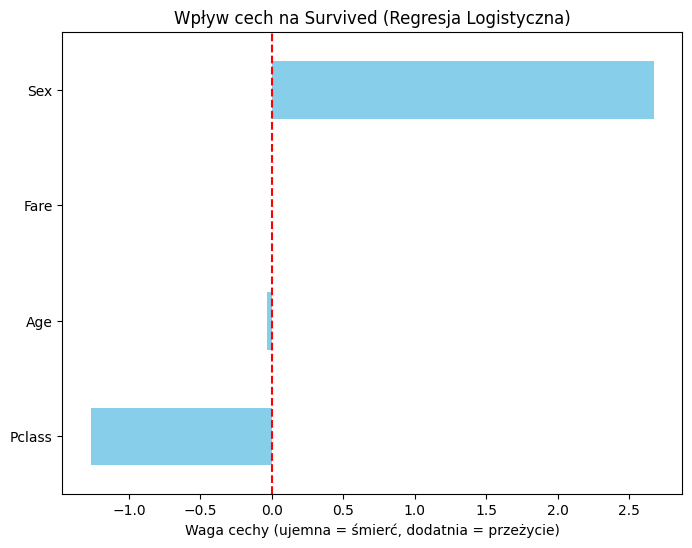

In [100]:
#potem zwizualizuj to wszystko i pobadaj hiperparametrey bo idę na spacer.

#wizualizacja regresji logistycznej
import matplotlib.pyplot as plt
wagi = pd.Series(log_reg.coef_[0], index=X_train.columns)

#wykres słupkowy
plt.figure(figsize=(8, 6))
wagi.sort_values().plot(kind='barh', color='skyblue')
plt.title("Wpływ cech na Survived (Regresja Logistyczna)")
plt.xlabel("Waga cechy (ujemna = śmierć, dodatnia = przeżycie)")
plt.axvline(x=0, color='red', linestyle='--') # Dodajemy czerwoną linię na zerze
plt.show()

##WNIOSKI:
- Czyli, wpływają na wynik tylko Pclass i Sex... Czyli warto dobrać inne parametry.

Edit: Spróbowałam, ale nic szczególnie nie wpływa. Czasami wynik nawet się pogarsza.

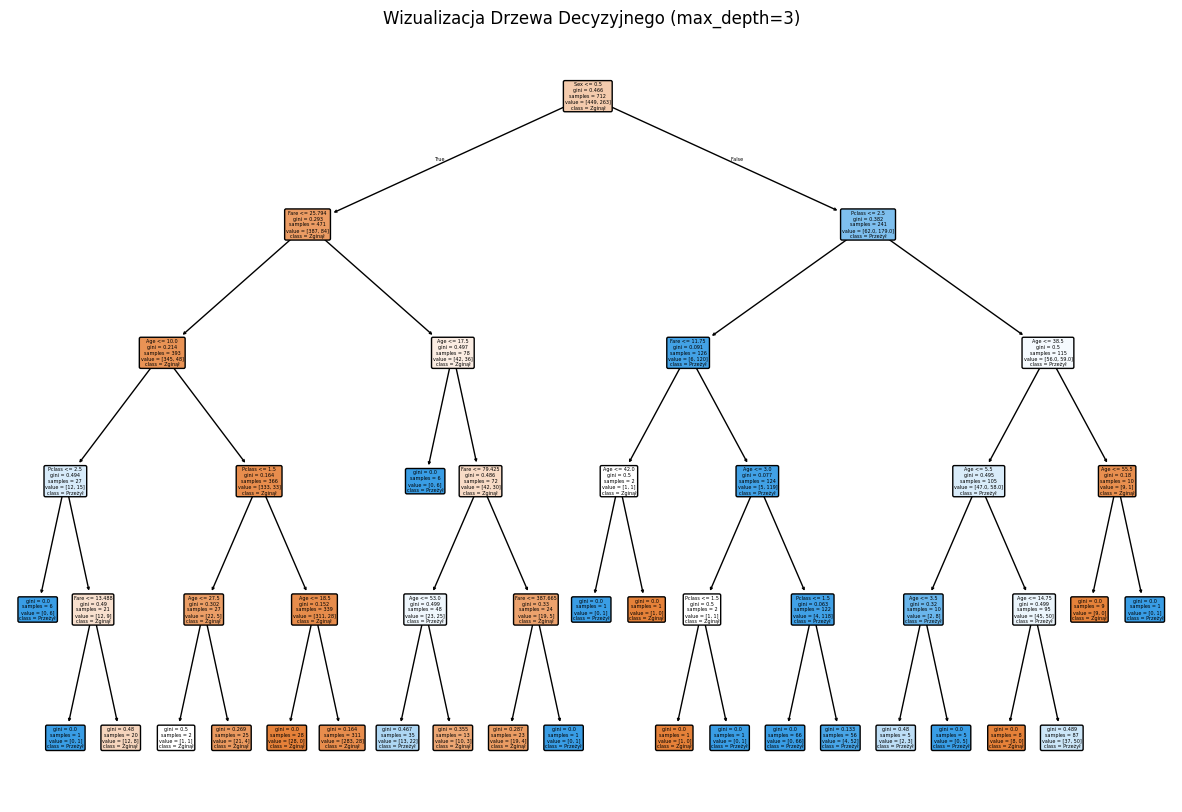

In [101]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 10)) # Ustawiamy duży rozmiar obrazka
plot_tree(model_drzewo,
          feature_names=X_train.columns, # Nazwy Twoich kolumn (np. Wiek, Płeć)
          class_names=['Zginął', 'Przeżył'], # Nazwy klas
          filled=True,   # Koloruje pola (np. niebieski dla przeżycia, pomarańczowy dla śmierci)
          rounded=True)  # Zaokrągla rogi, żeby wyglądało ładniej
plt.title("Wizualizacja Drzewa Decyzyjnego (max_depth=3)")
plt.show()

##WNIOSKI:

faktycznie, już pierwszy poziom w większości filtruje szanse na przeżycie. Lewe skrzydło - przeżycie, Prawe - śmierć.

Faktycznie, dodałam 5 poziomów, ponieważ na nim był najlepszy wynik. Jak tylko zmniejszamy lub zwiększamy - model albo się przeucza albo się niedoucza.

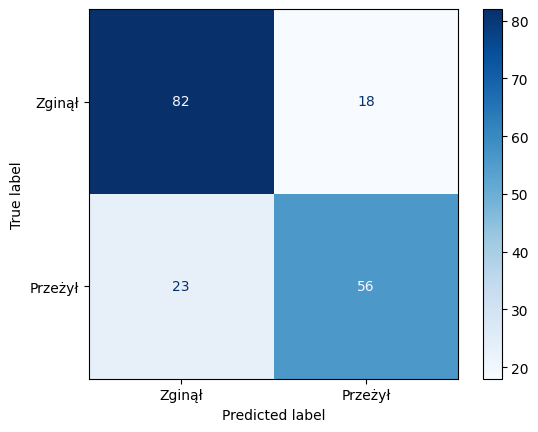

In [102]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(log_reg, X_test, y_test,
                                      display_labels=['Zginął', 'Przeżył'],
                                      cmap='Blues')
plt.show()

Ciekawy jest fakt tego, że obaj modele najlepiej markują zginęłszych aniżeli żywych.

Podejrzewam, że zdarza się to przez to, że większość pasażerów zginęła. A przynajmniej tak jest w danym zbiorze danych.

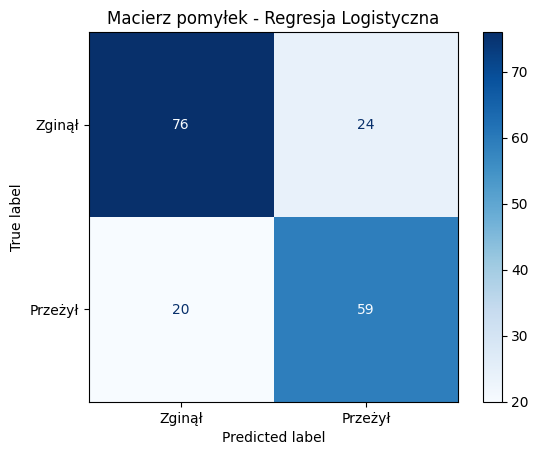

In [103]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model_drzewo, X_test, y_test,
                                      display_labels=['Zginął', 'Przeżył'],
                                      cmap='Blues')
plt.title("Macierz pomyłek - Regresja Logistyczna")
plt.show()

Podobnie do ubiegłego case'u.